In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt 
import seaborn as sns
import nltk


In [2]:
df= pd.read_csv("Reviews.csv")
print(df.shape)
df= df.head(200000)
print(df.shape)

(568454, 10)
(200000, 10)


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df["Score"].value_counts()

Score
5    126387
4     29118
1     18296
3     15624
2     10575
Name: count, dtype: int64

In [5]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,200000.000000,200000.000000,200000.000000,200000.000000,2.000000e+05
mean,100000.500000,1.704565,2.189235,4.173625,1.295963e+09
std,57735.171256,7.119707,7.740150,1.309480,4.772918e+07
min,1.000000,0.000000,0.000000,1.000000,9.393408e+08
25%,50000.750000,0.000000,0.000000,4.000000,1.270426e+09
50%,100000.500000,0.000000,1.000000,5.000000,1.310602e+09
75%,150000.250000,2.000000,2.000000,5.000000,1.332461e+09
max,200000.000000,866.000000,878.000000,5.000000,1.351210e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      200000 non-null  int64 
 1   ProductId               200000 non-null  object
 2   UserId                  200000 non-null  object
 3   ProfileName             199988 non-null  object
 4   HelpfulnessNumerator    200000 non-null  int64 
 5   HelpfulnessDenominator  200000 non-null  int64 
 6   Score                   200000 non-null  int64 
 7   Time                    200000 non-null  int64 
 8   Summary                 199992 non-null  object
 9   Text                    200000 non-null  object
dtypes: int64(5), object(5)
memory usage: 15.3+ MB


In [7]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
sia= SentimentIntensityAnalyzer()

In [ ]:
sia.polarity_scores("i am happy")

{'neg': 0.0, 'neu': 0.43, 'pos': 0.57, 'compound': 0.6096}

In [10]:
ps_df={}
for i, row in tqdm(df.iterrows(),total=len(df)):
    text=row["Text"]
    id=row["Id"]
    ps_df[id] = sia.polarity_scores(text)

  0%|          | 0/200000 [00:00<?, ?it/s]

In [11]:
ps_df

{1: {'neg': 0.0, 'neu': 0.695, 'pos': 0.305, 'compound': 0.9441},
 2: {'neg': 0.138, 'neu': 0.862, 'pos': 0.0, 'compound': -0.5664},
 3: {'neg': 0.091, 'neu': 0.754, 'pos': 0.155, 'compound': 0.8265},
 4: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 5: {'neg': 0.0, 'neu': 0.552, 'pos': 0.448, 'compound': 0.9468},
 6: {'neg': 0.029, 'neu': 0.809, 'pos': 0.163, 'compound': 0.883},
 7: {'neg': 0.034, 'neu': 0.693, 'pos': 0.273, 'compound': 0.9346},
 8: {'neg': 0.0, 'neu': 0.52, 'pos': 0.48, 'compound': 0.9487},
 9: {'neg': 0.0, 'neu': 0.851, 'pos': 0.149, 'compound': 0.6369},
 10: {'neg': 0.0, 'neu': 0.705, 'pos': 0.295, 'compound': 0.8313},
 11: {'neg': 0.017, 'neu': 0.846, 'pos': 0.137, 'compound': 0.9746},
 12: {'neg': 0.113, 'neu': 0.887, 'pos': 0.0, 'compound': -0.7579},
 13: {'neg': 0.031, 'neu': 0.923, 'pos': 0.046, 'compound': 0.296},
 14: {'neg': 0.0, 'neu': 0.355, 'pos': 0.645, 'compound': 0.9466},
 15: {'neg': 0.104, 'neu': 0.632, 'pos': 0.264, 'compound': 0.6486},
 

In [12]:
pd.DataFrame(ps_df).T

,neg,neu,pos,compound
1,0.000,0.695,0.305,0.9441
2,0.138,0.862,0.000,-0.5664
3,0.091,0.754,0.155,0.8265
4,0.000,1.000,0.000,0.0000
5,0.000,0.552,0.448,0.9468
...,...,...,...,...
199996,0.000,0.788,0.212,0.5827
199997,0.042,0.750,0.208,0.9892
199998,0.190,0.777,0.033,-0.8732
199999,0.022,0.853,0.124,0.7430


In [ ]:
merged_df=pd.DataFrame(ps_df).T
merged_df=merged_df.reset_index().rename(columns={'index':'Id'})
merged_df=merged_df.merge(df, how='left')

In [14]:
merged_df.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Id                      200000 non-null  int64  
 1   neg                     200000 non-null  float64
 2   neu                     200000 non-null  float64
 3   pos                     200000 non-null  float64
 4   compound                200000 non-null  float64
 5   ProductId               200000 non-null  object 
 6   UserId                  200000 non-null  object 
 7   ProfileName             199988 non-null  object 
 8   HelpfulnessNumerator    200000 non-null  int64  
 9   HelpfulnessDenominator  200000 non-null  int64  
 10  Score                   200000 non-null  int64  
 11  Time                    200000 non-null  int64  
 12  Summary                 199992 non-null  object 
 13  Text                    200000 non-null  object 
dtypes: float64(4), int64

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(df["airline_sentiment"].value_counts(), labels=df["airline_sentiment"].value_counts().index, autopct="%1.1f%%")
plt.show()

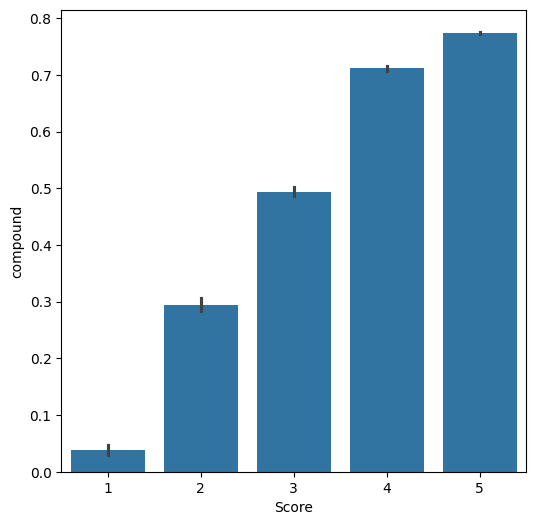

In [16]:
plt.figure(figsize=(6,6))
sns.barplot(data= merged_df, x='Score', y="compound")
plt.show()


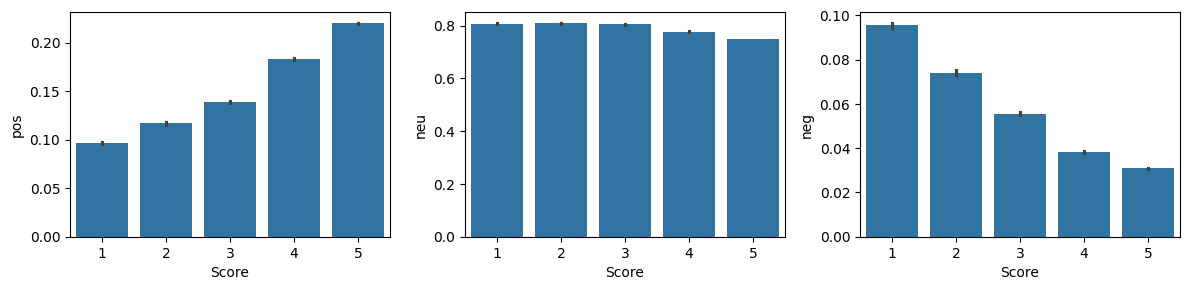

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=merged_df, x='Score', y="pos", ax=axes[0])
sns.barplot(data=merged_df, x='Score', y="neu", ax=axes[1])
sns.barplot(data=merged_df, x='Score', y="neg", ax=axes[2])

plt.tight_layout()
plt.show()

In [18]:
merged_df['class'] = merged_df['Score'].map({
    1: 'negative',
    2: 'negative',
    3: 'neutral',
    4: 'positive',
    5: 'positive'
})


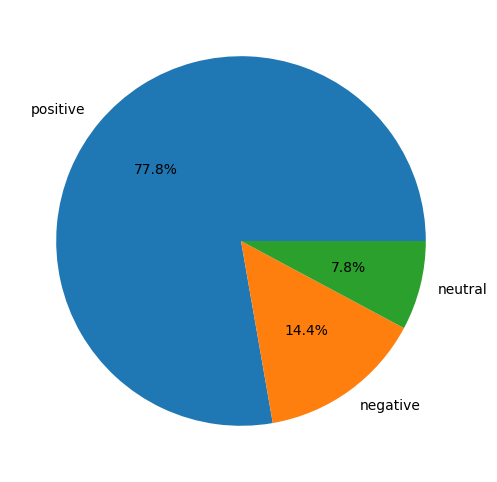

In [57]:
plt.figure(figsize=(6,6))
plt.pie(merged_df["class"].value_counts(), labels=merged_df["class"].value_counts().index, autopct="%1.1f%%")
plt.show()

In [19]:
print(merged_df['class'].value_counts())

class
positive    155505
negative     28871
neutral      15624
Name: count, dtype: int64


In [20]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state= 0)
df_bal,df_bal['class']=rus.fit_resample(merged_df[['Text']],merged_df['class'])
df_bal

,Text,class
193323,"This was thin, unlike the last xtra large that...",negative
159642,Buyer Beware Please! This sweetener is not for...,negative
120733,"This is not a typical K-Cup, this is a powder....",negative
45822,I got a sample serving of this tea from the Am...,negative
31201,"At first, I was impressed by these round littl...",negative
...,...,...
114122,Fig Newtons by Nabisco are an American staple ...,positive
148391,"This is a good, moderately bold coffee. Just ...",positive
153460,My border collie will no longer eat a snack un...,positive
126889,I got rid of the gopher which was in my backya...,positive


In [21]:
x = df_bal["Text"]
y=df_bal["class"]

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [23]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [24]:
x_train_cleaned = (
    x_train.str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
           .str.replace(r'\s+', ' ', regex=True)
           .str.strip()
           .str.lower()
)

x_test_cleaned = (
    x_test.str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
          .str.replace(r'\s+', ' ', regex=True)
          .str.strip()
          .str.lower()
)




In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(stop_words='english',ngram_range=(1, 2))

train_x_vector = tfidf.fit_transform(x_train_cleaned)

test_x_vector = tfidf.transform(x_test_cleaned)

In [26]:
print(df_bal.value_counts('class'))

class
negative    15624
neutral     15624
positive    15624
Name: count, dtype: int64


# models

In [27]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(train_x_vector, y_train)

SVC(kernel='linear')

In [28]:
y_pred= svc.predict(test_x_vector)
print(svc.score(test_x_vector,y_test))

0.7432533333333333


In [29]:
print(svc.predict(tfidf.transform(['i dont know'])))
print(svc.predict(tfidf.transform(['An excellent product i will buy again'])))
print(svc.predict(tfidf.transform(['I did not like this product at all I sold it'])))
text = """sizes recomended in the size chart are not real
sizes are much smaller than what is recomended in the chart. 
I tried to put it and sheer it!. I guess you should not buy this item in the internet..
it is better to go to the store and check it"""
print(svc.predict(tfidf.transform([text])))

['negative']
['positive']
['negative']
['negative']


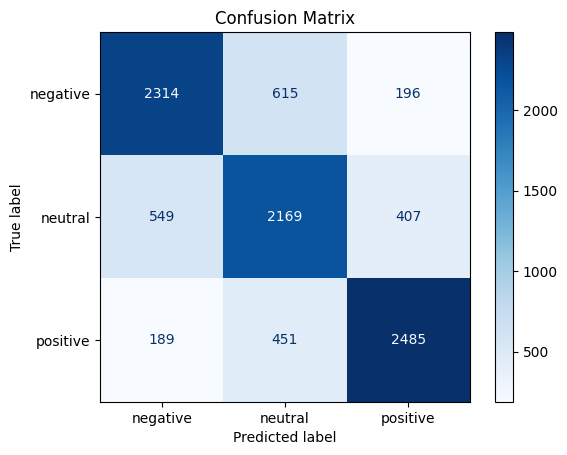

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)
classes = sorted(y_test.unique())


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt= DecisionTreeClassifier()
dt.fit(train_x_vector, y_train)

DecisionTreeClassifier()

In [33]:
y_pred1= dt.predict(test_x_vector)
print(dt.score(test_x_vector,y_test))

0.592


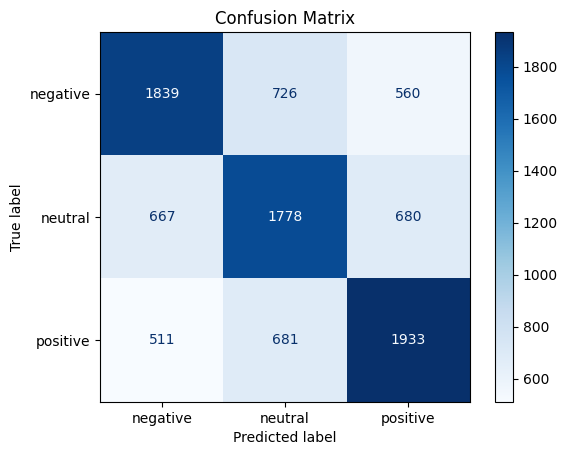

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred1)
classes = sorted(y_test.unique())


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB  

mnb = MultinomialNB()
mnb.fit(train_x_vector, y_train) 

MultinomialNB()

In [36]:
y_pred2= mnb.predict(test_x_vector)
print(mnb.score(test_x_vector,y_test))

0.70592


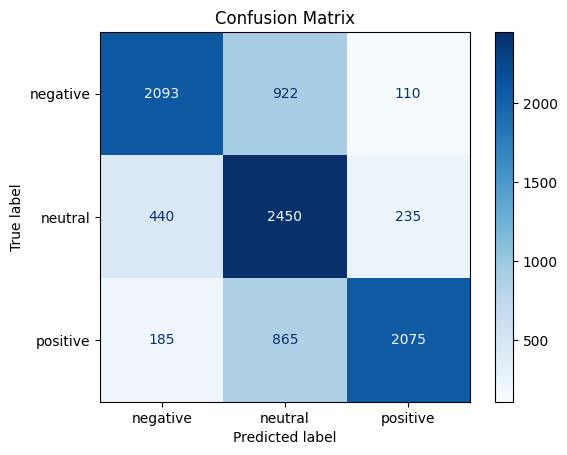

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred2)
classes = sorted(y_test.unique())


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=21)
rf.fit(train_x_vector,y_train)

RandomForestClassifier(random_state=21)

In [39]:
y_pred3= rf.predict(test_x_vector)
print(rf.score(test_x_vector,y_test))

0.7140266666666667


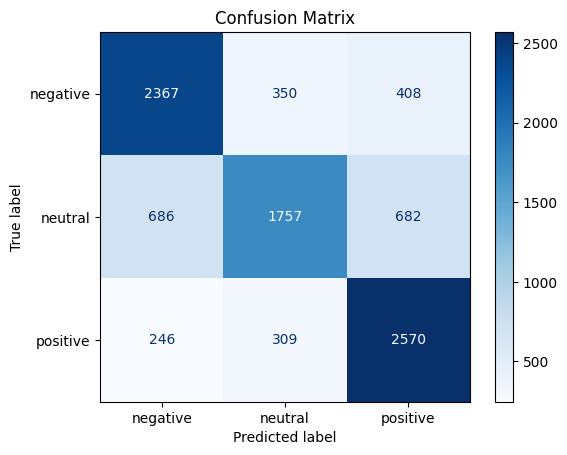

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred3)
classes = sorted(y_test.unique())


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [41]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression()
lr.fit(train_x_vector,y_train)

C:\Users\LENOVO\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [42]:
y_pred4= lr.predict(test_x_vector)
print(lr.score(test_x_vector,y_test))

0.7364266666666667


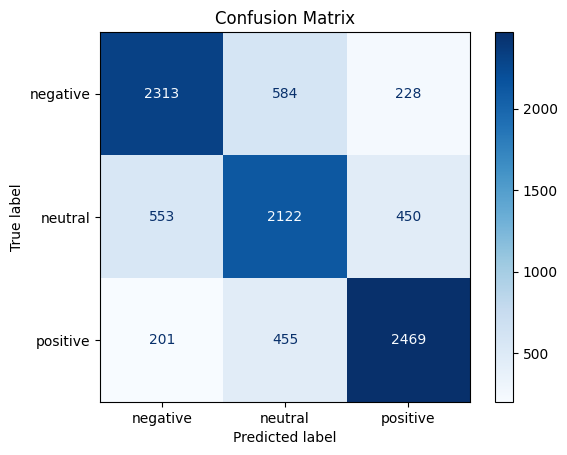

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred4)
classes = sorted(y_test.unique())


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [44]:
from sklearn.metrics import classification_report, accuracy_score
models_predictions = {
    "Logistic Regression": (y_test, y_pred4),
    "Random Forest": (y_test, y_pred3),
    "SVM": (y_test, y_pred),
    "Decision tree": (y_test, y_pred1),
    "Multinom nb": (y_test, y_pred2)
    
}


for model_name, (test, pred) in models_predictions.items():
    print(f"\n{'-'*40}\n{model_name}\n{'-'*40}")
    print(f"Accuracy: {accuracy_score(test, pred):.2f}")
    print(classification_report(test, pred))


----------------------------------------
Logistic Regression
----------------------------------------
Accuracy: 0.74
              precision    recall  f1-score   support

    negative       0.75      0.74      0.75      3125
     neutral       0.67      0.68      0.68      3125
    positive       0.78      0.79      0.79      3125

    accuracy                           0.74      9375
   macro avg       0.74      0.74      0.74      9375
weighted avg       0.74      0.74      0.74      9375


----------------------------------------
Random Forest
----------------------------------------
Accuracy: 0.71
              precision    recall  f1-score   support

    negative       0.72      0.76      0.74      3125
     neutral       0.73      0.56      0.63      3125
    positive       0.70      0.82      0.76      3125

    accuracy                           0.71      9375
   macro avg       0.72      0.71      0.71      9375
weighted avg       0.72      0.71      0.71      9375


-------

In [52]:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    text = text.lower()
    return text

while True:
    user_input = input("Enter text to classify (or type 'quit' to exit): ")
    if user_input.lower() == 'quit':
        print("Exiting prediction loop.")
        break
    cleaned = clean_text(user_input)
    vect = tfidf.transform([cleaned])  
    pred = svc.predict(vect)           
    print(f"Predicted label: {pred[0]}")


Predicted label: negative
Exiting prediction loop.


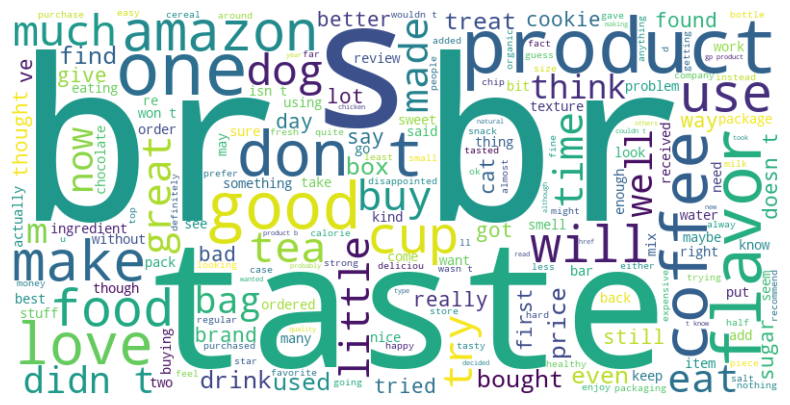

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

subset_texts = x_train_cleaned[:100000]
processed_texts = []
for item in subset_texts:
    if isinstance(item, list):
       
        processed_texts.append(' '.join(item))
    else:
        
        processed_texts.append(item)

text = ' '.join(processed_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
